## Exploratory Model Comparison using AqSolDBc

In [1]:
"""Importing all required libraries """
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, rdFingerprintGenerator
from rdkit import RDLogger
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

### Featurisation and Cleaning

In [2]:
def generate_and_clean_features(df, smiles_col='SMILES', target_col='ExperimentalLogS'):
    # Extract valid SMILES and Target
    X_smiles = df[smiles_col].values
    y = df[target_col].values
    
    fps = []
    desc_list = []
    valid_indices = []
    
    # Get all RDKit descriptor names
    desc_names = [n[0] for n in Descriptors._descList]
    
    # Initialize the modern Morgan Generator (radius 2, 2048 bits)
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    
    print("1. Generating RDKit Descriptors and Morgan Fingerprints...")
    for i, smiles in enumerate(tqdm(X_smiles)):
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            # Generate Morgan Fingerprint using the new generator
            fp = mfpgen.GetFingerprint(mol)
            fps.append(list(fp))
            
            # RDKit Descriptors
            descs = [f(mol) for _, f in Descriptors._descList]
            desc_list.append(descs)
            
            valid_indices.append(i)
            
    # Convert to DataFrames
    df_fp = pd.DataFrame(fps, columns=[f'MF_{i}' for i in range(2048)])
    df_desc = pd.DataFrame(desc_list, columns=desc_names)
    
    # Combine features
    X = pd.concat([df_desc, df_fp], axis=1)
    y = y[valid_indices]
    
    # Ensure column names are compatible with models (especially XGBoost)
    X.columns = X.columns.str.replace(r'[\[\]<>]', '_', regex=True)
    
    # Convert 'inf' values to NaN so they get caught by the NaN filters
    X = X.replace([np.inf, -np.inf], np.nan)
    
    print("\n2. Applying NaN Handling Strategy...")
    
    # a. Remove IPC column
    if 'Ipc' in X.columns:
        X = X.drop(columns=['Ipc'])
        print("- Removed 'Ipc' column.")
        
    # b. Remove columns with > 10% NaNs
    threshold = 0.10 * len(X)
    nan_counts = X.isna().sum()
    cols_to_drop = nan_counts[nan_counts > threshold].index.tolist()
    if cols_to_drop:
        X = X.drop(columns=cols_to_drop)
        print(f"- Removed {len(cols_to_drop)} columns with > 10% NaNs:")
        print(f"  {cols_to_drop}")
    else:
        print("- No columns exceeded 10% NaN threshold.")
        
    # c. Drop rows (molecules) with NaNs left
    combined = X.copy()
    combined['TARGET_Y'] = y
    initial_rows = len(combined)
    combined = combined.dropna()
    dropped_rows = initial_rows - len(combined)
    
    y_clean = combined['TARGET_Y'].values
    X_clean = combined.drop(columns=['TARGET_Y'])
    print(f"- Dropped {dropped_rows} rows (molecules) containing remaining NaNs.")
    
    return X_clean, y_clean

### Data Loading, Model Training and Plot Output

1. Generating RDKit Descriptors and Morgan Fingerprints...


  3%|▎         | 245/8043 [00:02<01:09, 111.60it/s][11:00:58] WARNING: not removing hydrogen atom without neighbors
[11:00:58] WARNING: not removing hydrogen atom without neighbors
[11:00:58] WARNING: not removing hydrogen atom without neighbors
[11:00:58] WARNING: not removing hydrogen atom without neighbors
  5%|▌         | 420/8043 [00:04<01:17, 98.10it/s] [11:01:00] WARNING: not removing hydrogen atom without neighbors
[11:01:00] WARNING: not removing hydrogen atom without neighbors
  8%|▊         | 681/8043 [00:06<01:04, 113.42it/s][11:01:02] WARNING: not removing hydrogen atom without neighbors
[11:01:02] WARNING: not removing hydrogen atom without neighbors
 12%|█▏        | 963/8043 [00:10<01:52, 62.87it/s] [11:01:06] WARNING: not removing hydrogen atom without neighbors
[11:01:06] WARNING: not removing hydrogen atom without neighbors
 13%|█▎        | 1032/8043 [00:11<02:50, 41.06it/s][11:01:07] WARNING: not removing hydrogen atom without neighbors
[11:01:07] WARNING: not removi


2. Applying NaN Handling Strategy...
- Removed 'Ipc' column.
- No columns exceeded 10% NaN threshold.
- Dropped 310 rows (molecules) containing remaining NaNs.

Training Random Forest...
Training XGBoost...
RF Metrics: R2=0.854, RMSE=0.894, MAE=0.624
XGB Metrics: R2=0.870, RMSE=0.843, MAE=0.589


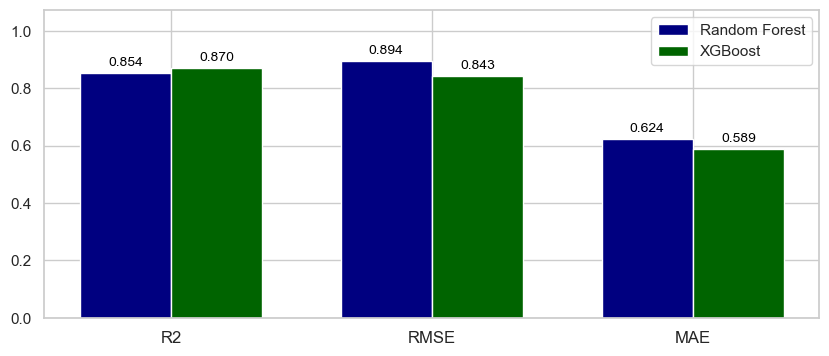

In [5]:
# 1. Load and filter curated AqSolDBc
df_aqsoldbc = pd.read_csv('AqSolDBc.csv')
df_aqsoldbc = df_aqsoldbc.dropna(subset=["SMILES", "ExperimentalLogS"])
df_aqsoldbc = df_aqsoldbc.drop_duplicates(subset=['SMILES'])
df_aqsoldbc = df_aqsoldbc[(df_aqsoldbc['ExperimentalLogS'] > -12) & (df_aqsoldbc['ExperimentalLogS'] < 2)]

# 2. Featurize and Clean
X_aqc, y_aqc = generate_and_clean_features(df_aqsoldbc, smiles_col='SMILES', target_col='ExperimentalLogS')

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_aqc, y_aqc, test_size=0.2, random_state=42)

# 4. Scale features (using ONE scalar for both models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Random Forest 

print("\nTraining Random Forest...")
rf = RandomForestRegressor(
    n_estimators=500, 
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)


print("Training XGBoost...")
xgb = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42, 
    n_jobs=-1
)
xgb.fit(X_train_scaled, y_train)
xgb_pred = xgb.predict(X_test_scaled)

# 7. Calculate Metrics Function (Percentages removed)
def get_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return [r2, rmse, mae]

rf_metrics = get_metrics(y_test, rf_pred)
xgb_metrics = get_metrics(y_test, xgb_pred)

print(f"RF Metrics: R2={rf_metrics[0]:.3f}, RMSE={rf_metrics[1]:.3f}, MAE={rf_metrics[2]:.3f}")
print(f"XGB Metrics: R2={xgb_metrics[0]:.3f}, RMSE={xgb_metrics[1]:.3f}, MAE={xgb_metrics[2]:.3f}")

# 8. Plot Comparative Bar Graph (Grouped by Metric)
sns.set_theme(style="whitegrid")

# Approx 10 width, ~4.0 height (slightly taller to ensure numbers on top fit nicely)
plt.figure(figsize=(10, 4)) 

metric_names = ['R2', 'RMSE', 'MAE']
x = np.arange(len(metric_names))
width = 0.35

# Plot bars and store them in variables
bars_rf = plt.bar(x - width/2, rf_metrics, width, label='Random Forest', color='navy')
bars_xgb = plt.bar(x + width/2, xgb_metrics, width, label='XGBoost', color='darkgreen')

# Add values on top of the bars
plt.bar_label(bars_rf, fmt='%.3f', padding=3, fontsize=10, color='black')
plt.bar_label(bars_xgb, fmt='%.3f', padding=3, fontsize=10, color='black')

plt.xticks(x, metric_names, fontsize=12)
plt.legend(loc='upper right')

# Dynamically scale the y-axis so the text labels aren't cut off by the top of the chart
max_value = max(max(rf_metrics), max(xgb_metrics))
plt.ylim(0, max_value * 1.2)

plt.show()